In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
methods_names = {
    "dist_linguistic_confidence": "Dist. Ling. Conf.",
    "dist_semantic_uncertainty": "Dist. Semantic Unc.",
    "dist_lnll": "Dist. Token Prob"
}

dataset_size = {
    "mmlu": 116000,
    "squadv2": 130000,
    "truthful_qa": 817
}

dataset_map = {
    "mmlu": "MMLU",
    "squadv2": "SQuAD2.0",
    "truthful_qa": "TruthfulQA"
}

model_name_map = {
    "Llama-3.1-8B-Instruct": "Llama-3.1-8B-Inst.",
    "Meta-Llama-3-8B-Instruct": "Llama-3-8B-Inst.",
    "Qwen2.5-7B-Instruct": "Qwen2.5-7B-Inst.",
    "Qwen3-8B": "Qwen3-8B-Inst.",
    "Mistral-7B-Instruct-v0.3": "Mistral-7B-Inst.",
    "gpt-oss-20b": "GPT-OSS-20B",
}

In [3]:
prompt_type = "direct_qa"

In [4]:
results_dir = f"/hdd/ivny/{prompt_type}_in_domain_calibration"

# list all leaf nodes in results_dir
leaf_dirs = []
for root, dirs, files in os.walk(results_dir):
    if not dirs:  # if there are no subdirectories, it's a leaf node
        leaf_dirs.append(root)

all_records = []
for leaf_dir in leaf_dirs:
    _, _, _, _, dataset_name, _, model_name = leaf_dir.split("/")
    if os.path.exists(os.path.join(leaf_dir, "calibration_performance.csv")):
        csv_data = pd.read_csv(os.path.join(leaf_dir, "calibration_performance.csv"), index_col=0)
        csv_records = csv_data.transpose().to_dict("records")

        for record in csv_records:
            record["dataset"] = dataset_map.get(dataset_name, dataset_name)
            record["model"] = model_name_map.get(model_name, model_name)
            record["dataset_size"] = dataset_size.get(dataset_name, None)

        all_records.extend(csv_records)
    else:
        print(model_name, dataset_name, "missing calibration_performance.csv")

In [5]:
# mean_df = pd.DataFrame(all_records).drop(columns=["dataset"]).groupby(["model"]).mean().reset_index()
# mean_df

df = pd.DataFrame(all_records).drop(columns=["dataset"])

group_cols = ["model"]
weight_col = "dataset_size"
metric_cols = [c for c in df.columns if c not in group_cols + [weight_col]]

def weighted_avg_by_group(group):
    weights = pd.to_numeric(group[weight_col], errors="coerce").fillna(0)
    out = {}
    for col in metric_cols:
        values = pd.to_numeric(group[col], errors="coerce")
        mask = values.notna() & (weights > 0)
        if mask.any():
            out[col] = np.average(values[mask], weights=weights[mask])
        else:
            out[col] = values.mean()
    return pd.Series(out)

dataset_weighted_average_mean = (
    df.groupby(group_cols)
    .apply(weighted_avg_by_group)
    .reset_index()
)

dataset_weighted_average_mean

,model,original_lc_generalised_ECE,original_lc_faithfulness_divergence,original_lc_ece_mean,original_lc_dAUROC,original_lc_auroc_mean,original_tp_generalised_ECE,original_tp_faithfulness_divergence,original_tp_ece_mean,original_tp_dAUROC,...,calibrated_tp_rewritten_lc_generalised_ECE,calibrated_tp_rewritten_lc_faithfulness_divergence,calibrated_tp_rewritten_lc_ece_mean,calibrated_tp_rewritten_lc_dAUROC,calibrated_tp_rewritten_lc_auroc_mean,calibrated_su_rewritten_lc_generalised_ECE,calibrated_su_rewritten_lc_faithfulness_divergence,calibrated_su_rewritten_lc_ece_mean,calibrated_su_rewritten_lc_dAUROC,calibrated_su_rewritten_lc_auroc_mean
0,GPT-OSS-20B,0.328675,3.066611,0.294305,0.495067,0.497313,0.182212,1.355009,0.151620,0.562220,...,0.162441,0.629653,0.096444,0.544882,0.563864,0.146977,0.564450,0.107965,0.621994,0.652010
1,Llama-3.1-8B-Inst.,0.264954,1.791028,0.245537,0.563175,0.584714,0.143141,0.537627,0.121214,0.650718,...,0.120832,0.602175,0.078786,0.625024,0.667937,0.111118,0.619357,0.093542,0.610402,0.656752
2,Mistral-7B-Inst.,0.350036,2.198273,0.314995,0.497346,0.495866,0.293546,43.130988,0.290385,0.630050,...,0.129323,0.544762,0.077149,0.561899,0.604687,0.150364,0.590038,0.109121,0.535613,0.561204
3,Qwen3-8B-Inst.,0.280823,1.933604,0.247739,0.515110,0.528811,0.334169,155.917781,0.332645,0.619863,...,0.127797,0.574978,0.077021,0.529628,0.551390,0.126044,0.617969,0.082942,0.554781,0.579601


In [6]:
mean_df = dataset_weighted_average_mean

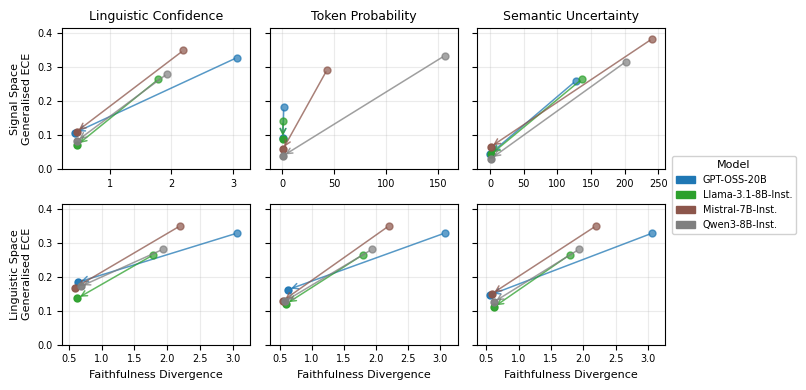

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


def _plot_arrow_grid(df, panel_rows, row_labels, filename):
    fig, axes = plt.subplots(2, 3, figsize=(8, 4), sharex=False, sharey=True)

    models = df["model"].unique().tolist()
    cmap = plt.colormaps["tab10"]
    model_colors = {m: cmap(i / max(len(models), 1)) for i, m in enumerate(models)}

    # Shared y-axis across all panels, always anchored at 0.
    all_y_vals = []
    for row_panels in panel_rows:
        for p in row_panels:
            all_y_vals.extend(df[p["y_from"]].tolist())
            all_y_vals.extend(df[p["y_to"]].tolist())
    global_y_max = max(all_y_vals) if all_y_vals else 0.0
    y_top = max(global_y_max * 1.08, 1e-6)

    for r, row_panels in enumerate(panel_rows):
        for c, p in enumerate(row_panels):
            ax = axes[r, c]
            x_vals = df[p["x_from"]].tolist() + df[p["x_to"]].tolist()
            finite_x_vals = [x for x in x_vals if np.isfinite(x)]
            if not finite_x_vals:
                ax.set_visible(False)
                continue

            x_min, x_max = min(finite_x_vals), max(finite_x_vals)

            for _, row in df.iterrows():
                x0, y0 = row[p["x_from"]], row[p["y_from"]]
                x1, y1 = row[p["x_to"]], row[p["y_to"]]
                color = model_colors[row["model"]]

                if not (np.isfinite(x0) and np.isfinite(x1)):
                    continue

                ax.scatter(x0, y0, color=color, s=25, alpha=0.7, zorder=3)
                ax.scatter(x1, y1, color=color, s=25, alpha=0.95, zorder=3)
                ax.annotate(
                    "",
                    xy=(x1, y1),
                    xytext=(x0, y0),
                    arrowprops=dict(arrowstyle="->", lw=1.1, alpha=0.75, color=color),
                )

            if np.isclose(x_min, x_max):
                x_pad = max(abs(x_min) * 0.1, 1e-6)
            else:
                x_pad = (x_max - x_min) * 0.08
            ax.set_xlim(x_min - x_pad, x_max + x_pad)
            ax.set_ylim(0, y_top)

            if r == 0:
                ax.set_title(p["title"], fontsize=9)
            else:
                ax.set_title("")

            ax.grid(alpha=0.25, which="major")
            ax.tick_params(labelsize=7)

            if r == 1:
                ax.set_xlabel("Faithfulness Divergence", fontsize=8)

    axes[0, 0].set_ylabel(f"{row_labels[0]}\nGeneralised ECE", fontsize=8)
    axes[1, 0].set_ylabel(f"{row_labels[1]}\nGeneralised ECE", fontsize=8)

    handles = [mpatches.Patch(color=model_colors[m], label=m) for m in models]
    fig.legend(
        handles=handles,
        title="Model",
        title_fontsize=8,
        fontsize=7,
        loc="center left",
        ncol=1,
        bbox_to_anchor=(0.84, 0.5),
        frameon=True,
        framealpha=0.9,
        edgecolor="#cccccc",
    )

    fig.tight_layout(rect=[0, 0, 0.86, 1])
    plt.savefig(filename + ".pdf", dpi=300, bbox_inches="tight")


panels_signal_space = [
    {
        "title": "Linguistic Confidence",
        "x_from": "original_lc_faithfulness_divergence",
        "y_from": "original_lc_generalised_ECE",
        "x_to": "calibrated_lc_faithfulness_divergence",
        "y_to": "calibrated_lc_generalised_ECE",
    },
    {
        "title": "Token Probability",
        "x_from": "original_tp_faithfulness_divergence",
        "y_from": "original_tp_generalised_ECE",
        "x_to": "calibrated_tp_faithfulness_divergence",
        "y_to": "calibrated_tp_generalised_ECE",
    },
    {
        "title": "Semantic Uncertainty",
        "x_from": "original_su_faithfulness_divergence",
        "y_from": "original_su_generalised_ECE",
        "x_to": "calibrated_su_faithfulness_divergence",
        "y_to": "calibrated_su_generalised_ECE",
    },
]

panels_linguistic_space = [
    {
        "title": "Linguistic Confidence",
        "x_from": "original_lc_faithfulness_divergence",
        "y_from": "original_lc_generalised_ECE",
        "x_to": "calibrated_lc_rewritten_lc_faithfulness_divergence",
        "y_to": "calibrated_lc_rewritten_lc_generalised_ECE",
    },
    {
        "title": "Token Probability",
        "x_from": "original_lc_faithfulness_divergence",
        "y_from": "original_lc_generalised_ECE",
        "x_to": "calibrated_tp_rewritten_lc_faithfulness_divergence",
        "y_to": "calibrated_tp_rewritten_lc_generalised_ECE",
    },
    {
        "title": "Semantic Uncertainty",
        "x_from": "original_lc_faithfulness_divergence",
        "y_from": "original_lc_generalised_ECE",
        "x_to": "calibrated_su_rewritten_lc_faithfulness_divergence",
        "y_to": "calibrated_su_rewritten_lc_generalised_ECE",
    },
]

_plot_arrow_grid(
    mean_df,
    [panels_signal_space, panels_linguistic_space],
    ["Signal Space", "Linguistic Space"],
    f"in_domain_calibration_{prompt_type}_combined_spaces",
)